In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("fivethirtyeight")

In [8]:
df = pd.read_excel("Churn Dataset_Netflix.xlsx")


In [9]:

df.head()

,customer_id,age,gender,subscription_type,last_login_days,region,device,monthly_fee,churn,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Female,Basic,29,Uttar Pradesh,TV,199,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Female,Standard,19,Uttar Pradesh,Mobile,499,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,10,Uttar Pradesh,TV,499,0,UPI,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Male,Premium,12,Uttar Pradesh,TV,649,1,UPI,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Male,Standard,13,Uttar Pradesh,Mobile,499,1,UPI,2,0.13,Action


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   last_login_days         5000 non-null   int64  
 5   region                  5000 non-null   str    
 6   device                  5000 non-null   str    
 7   monthly_fee             5000 non-null   int64  
 8   churn                   5000 non-null   int64  
 9   payment_method          5000 non-null   str    
 10  number_of_profiles      5000 non-null   int64  
 11  avg_watch_time_per_day  5000 non-null   float64
 12  favorite_genre          5000 non-null   str    
dtypes: float64(1), int64(5), str(7)
memory usage: 883.7 KB


In [11]:
df.drop(columns = ['customer_id'], inplace=True)

In [56]:
df.isnull().sum()

age                       0
gender                    0
subscription_type         0
last_login_days           0
region                    0
device                    0
monthly_fee               0
churn                     0
payment_method            0
number_of_profiles        0
avg_watch_time_per_day    0
favorite_genre            0
Prediction                0
Churn Probability         0
Retention Strategy        0
dtype: int64

In [54]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Length: 5000, dtype: bool

In [13]:
for col in ['age', 'last_login_days', 'monthly_fee' ,'number_of_profiles', 'avg_watch_time_per_day']:
    print(col, len(df[df[col]== " "]))

age 0
last_login_days 0
monthly_fee 0
number_of_profiles 0
avg_watch_time_per_day 0


In [14]:
df['churn'].value_counts()

churn
1    2515
0    2485
Name: count, dtype: int64

In [15]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,5000.0,43.8474,15.501128,18.0,30.00,44.00,58.00,70.00
last_login_days,5000.0,30.0898,17.536078,0.0,15.00,30.00,45.00,60.00
monthly_fee,5000.0,431.6900,193.207996,149.0,199.00,499.00,649.00,649.00
churn,5000.0,0.5030,0.500041,0.0,0.00,1.00,1.00,1.00
number_of_profiles,5000.0,2.2952,1.498168,1.0,1.00,2.00,4.00,5.00
avg_watch_time_per_day,5000.0,0.8748,2.619824,0.0,0.11,0.29,0.72,98.42


In [16]:
def plot_distribution(df, column_name):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_name], kde = True)
    plt.title(f"Distribution of {column_name}")
    
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    plt.axvline(col_mean, color = "cyan", linestyle="solid", label="Mean")
    plt.axvline(col_median, color = "magenta", linestyle="solid", label="Median")
    
    plt.legend()
    
    plt.subplot(1, 2, 2)
    sns.boxplot(y  = df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.show()

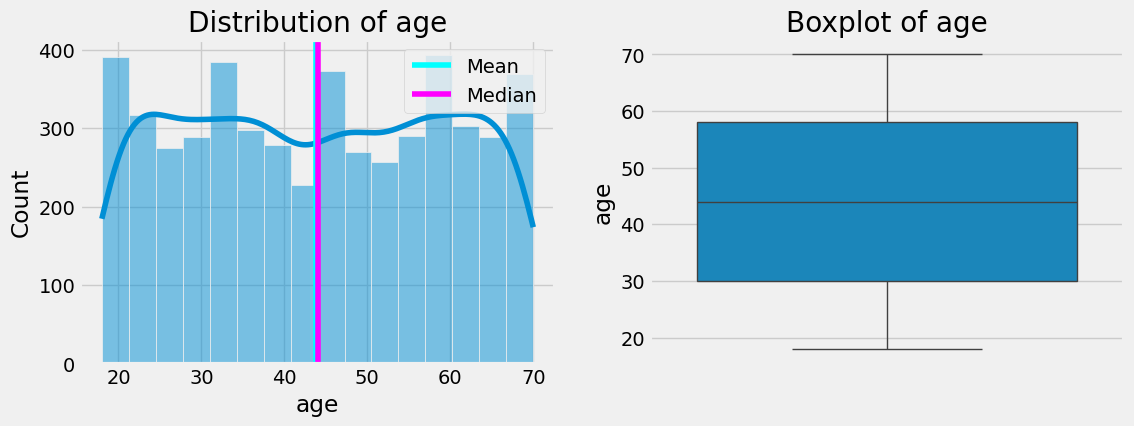

In [17]:
plot_distribution(df, "age")

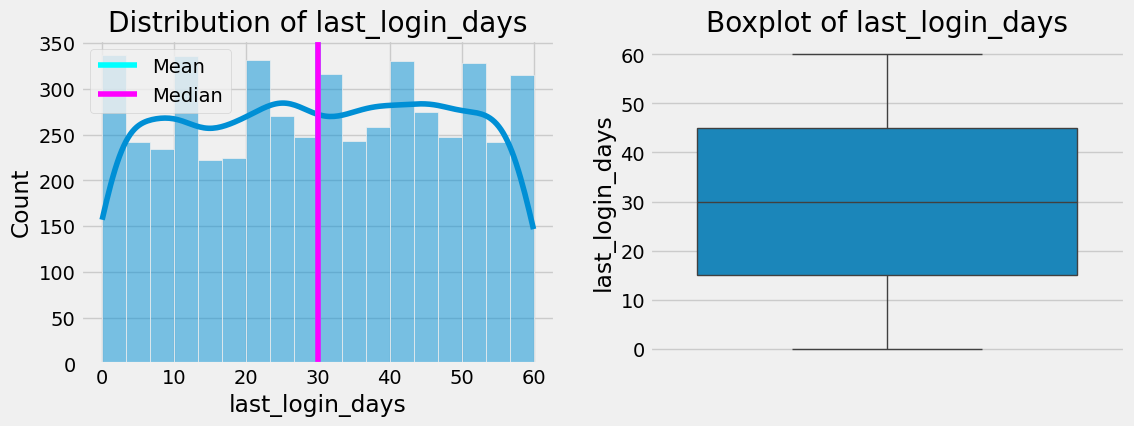

In [18]:
plot_distribution(df, "last_login_days")

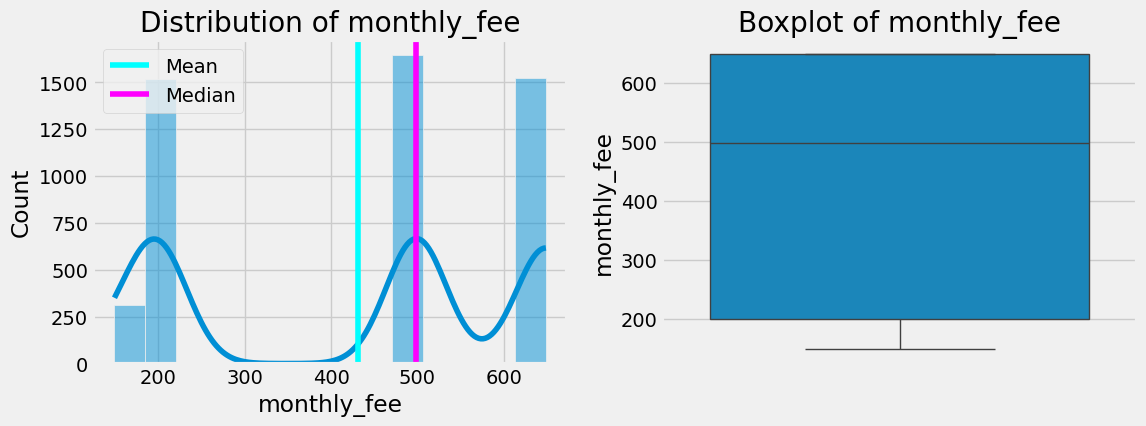

In [19]:
plot_distribution(df, "monthly_fee")

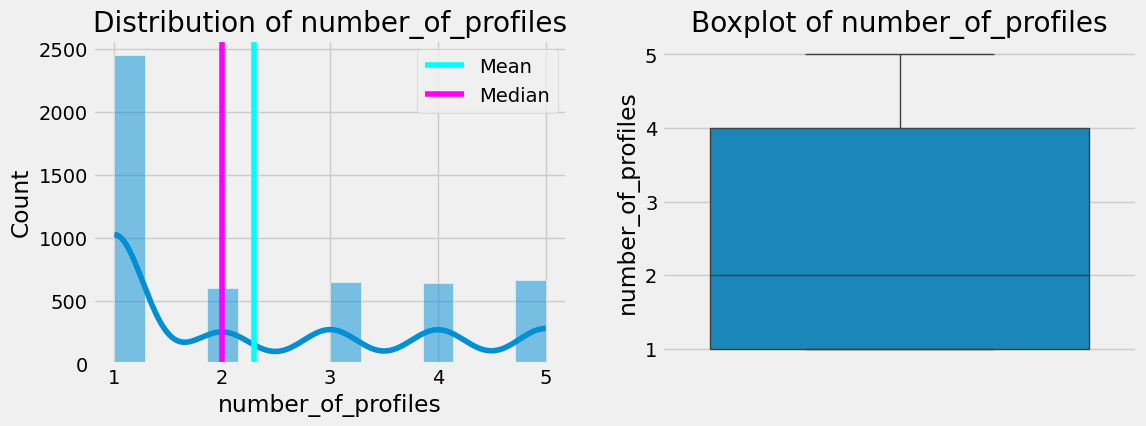

In [20]:
plot_distribution(df, "number_of_profiles")

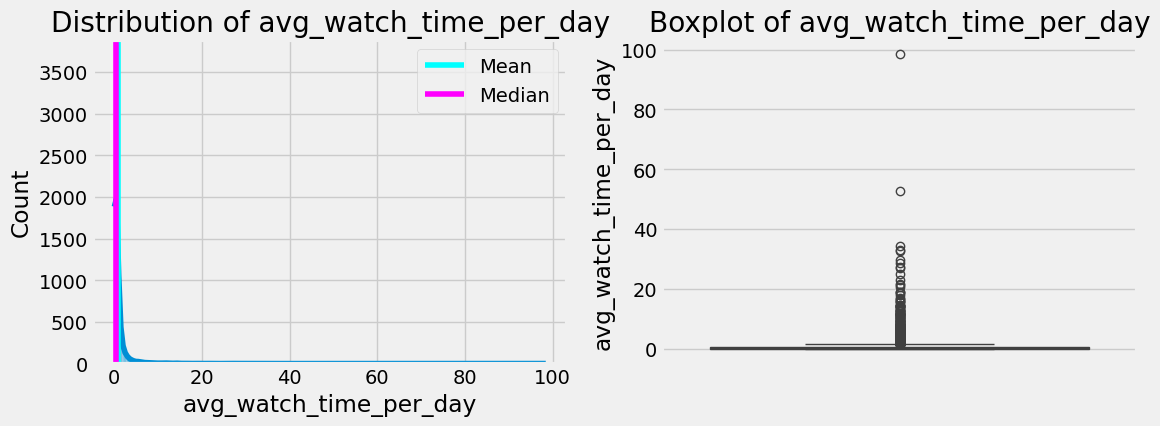

In [21]:
plot_distribution(df, "avg_watch_time_per_day")

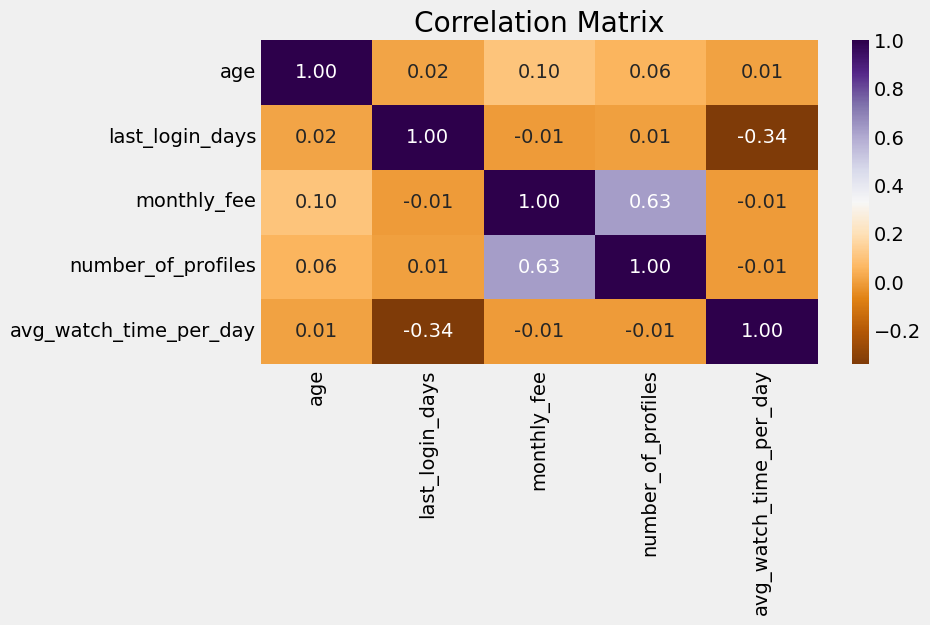

In [22]:
plt.figure(figsize = (8, 4))
sns.heatmap(df[['age', 'last_login_days', 'monthly_fee','number_of_profiles', 'avg_watch_time_per_day']].corr(), annot=True, cmap = "PuOr", fmt = ".2f")
plt.title("Correlation Matrix")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_22656\2053410207.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include = "object").columns.to_list()


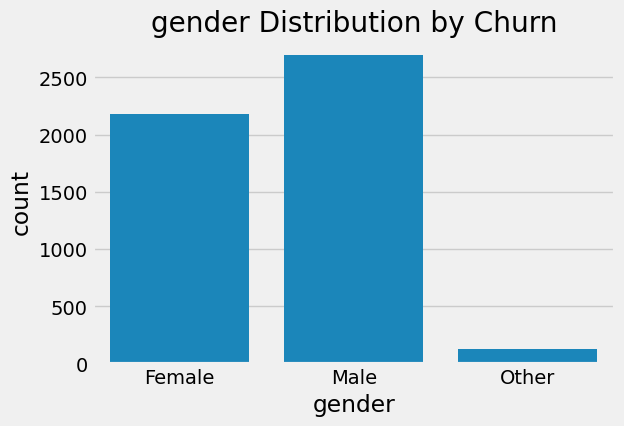

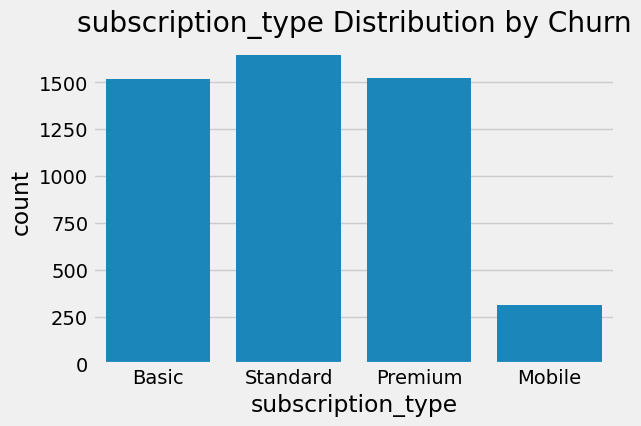

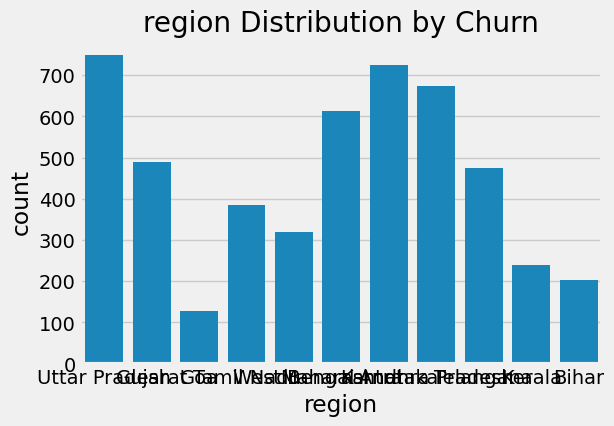

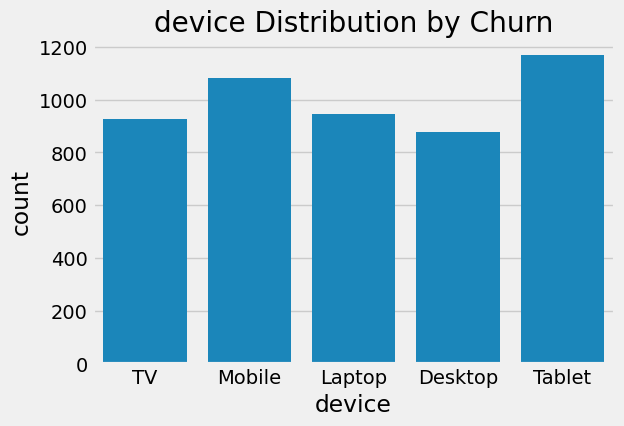

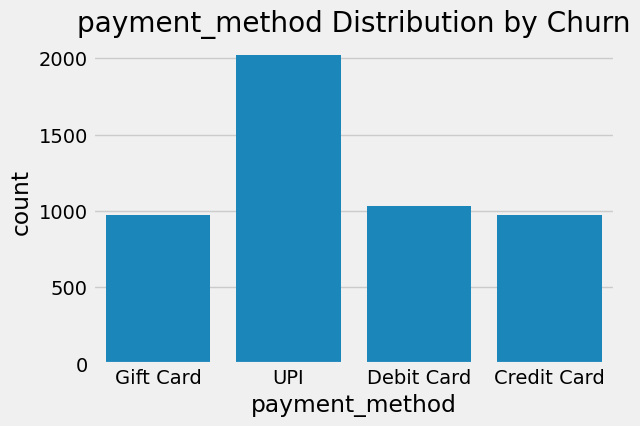

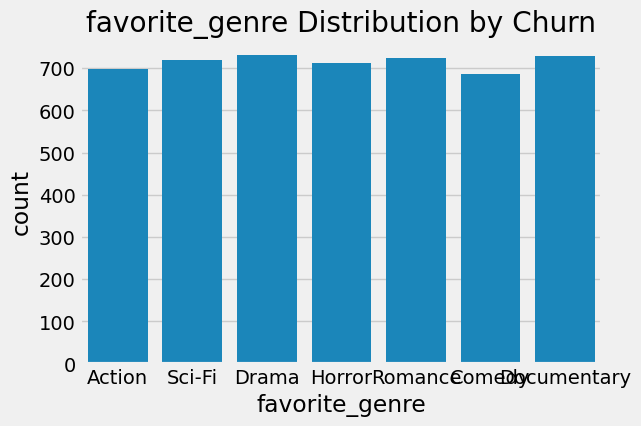

In [23]:
categorical_cols = df.select_dtypes(include = "object").columns.to_list()
for col in categorical_cols:
    plt.figure(figsize = (6, 4))
    sns.countplot(x = df[col])
    plt.title(f"{col} Distribution by Churn")
    plt.show()

In [24]:
str_columns = df.select_dtypes(include = "str").columns

In [25]:
str_columns

Index(['gender', 'subscription_type', 'region', 'device', 'payment_method',
       'favorite_genre'],
      dtype='str')

In [26]:
!pip install -q scikit-learn

from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in categorical_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

encoders = {}

!pip install -q scikit-learn


encoders = {}
for column in categorical_cols:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
encoders

{'gender': LabelEncoder(),
 'subscription_type': LabelEncoder(),
 'region': LabelEncoder(),
 'device': LabelEncoder(),
 'payment_method': LabelEncoder(),
 'favorite_genre': LabelEncoder()}

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     5000 non-null   int64  
 1   gender                  5000 non-null   int64  
 2   subscription_type       5000 non-null   int64  
 3   last_login_days         5000 non-null   int64  
 4   region                  5000 non-null   int64  
 5   device                  5000 non-null   int64  
 6   monthly_fee             5000 non-null   int64  
 7   churn                   5000 non-null   int64  
 8   payment_method          5000 non-null   int64  
 9   number_of_profiles      5000 non-null   int64  
 10  avg_watch_time_per_day  5000 non-null   float64
 11  favorite_genre          5000 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 468.9 KB


In [29]:
import pickle
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
numerical_cols = ['age', 'last_login_days', 'monthly_fee','number_of_profiles','avg_watch_time_per_day']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [32]:
df['churn'].value_counts()

churn
1    2515
0    2485
Name: count, dtype: int64

In [33]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [34]:
X = df.drop(columns = ['churn'])
y = df['churn']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}


In [37]:
hyperparameters = {

    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear", "lbfgs"]
    },

    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [5, 10, None]
    },

    "XGBoost": {
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7]
    }
}

In [38]:
best_models = {}
for model_name , model in models.items():
    print(f"Tunning {model_name}......")
    grid = GridSearchCV(estimator=model, param_grid=hyperparameters[model_name], cv=5, scoring = "accuracy")
    grid.fit(X_train, y_train)
    best_models[model_name] =grid.best_estimator_
    print(f"Best parameters for {model_name} : {grid.best_params_}")
    print(f"Best Accuracy for {model_name} : {grid.best_score_: .2f}\n")

Tunning Logistic Regression......
Best parameters for Logistic Regression : {'C': 100, 'solver': 'liblinear'}
Best Accuracy for Logistic Regression :  0.89

Tunning Random Forest......
Best parameters for Random Forest : {'max_depth': 10, 'n_estimators': 200}
Best Accuracy for Random Forest :  0.93

Tunning XGBoost......
Best parameters for XGBoost : {'learning_rate': 0.2, 'max_depth': 5}
Best Accuracy for XGBoost :  0.94



In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision  Recall  F1-Score
0  Logistic Regression     0.887     0.8556  0.9323    0.8923
1        Random Forest     0.917     0.9116  0.9243    0.9179
2              XGBoost     0.929     0.9389  0.9183    0.9285


In [40]:
import pickle
from xgboost import XGBClassifier
if 'customer_id' in df.columns:
    df = df.drop(columns=['customer_id'])
X = df.drop(columns=['churn'])
y = df['churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

loaded_model = XGBClassifier(n_estimators=100,random_state=42,max_depth=10,use_label_encoder=False,eval_metric='logloss')
loaded_model.fit(X_train, y_train)
filtered_encoders = {k: v for k, v in encoders.items() if k in df.columns}
encoders = filtered_encoders

# Save the objects for later use
with open("best_model.pkl", "wb") as f:
    pickle.dump(loaded_model, f)
    
with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)
    
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
    
scaler_data = scaler

c:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:05:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [41]:
def make_prediction(input_data):
    input_df = pd.DataFrame([input_data])
    
    # Get all columns the model expects
    expected_cols = loaded_model.feature_names_in_
    
    # Ensure all expected columns exist, fill missing ones with 0
    for col in expected_cols:
        if col not in input_df.columns:
            input_df[col] = 0
    
    # Apply label encoding to categorical columns
    for col in expected_cols:
        if col in encoders and col in input_df.columns:
            val = input_df[col].iloc[0]
            # Try to encode if it's not already a number
            if not isinstance(val, (int, float)):
                try:
                    # Try to transform
                    input_df[col] = encoders[col].transform(input_df[col])
                except ValueError:
                    # If value not in encoder classes, try to use a default value
                    # Get the first class value as fallback
                    input_df[col] = encoders[col].classes_[0]
                    input_df[col] = encoders[col].transform(input_df[col])
    
    # Apply scaling to numerical columns
    numerical_cols = ['age', 'last_login_days', 'monthly_fee','number_of_profiles','avg_watch_time_per_day']
    numerical_cols_present = [col for col in numerical_cols if col in expected_cols]
    
    if numerical_cols_present:
        input_df[numerical_cols_present] = scaler_data.transform(input_df[[col for col in numerical_cols_present]])
    
    # Select only the columns the model expects
    X_pred = input_df[expected_cols].astype(float)
    
    prediction = loaded_model.predict(X_pred)[0]
    probability = loaded_model.predict_proba(X_pred)[0, 1]
    
    churn_status = "Churn" if prediction == 1 else "No Churn"
    
    if probability >= 0.90:
        retention_strategy = (
            "Critical Risk: Contact the customer immediately, "
            "offer a premium retention package or significant discount, "
            "and assign a dedicated support representative."
        )
    elif probability >= 0.75:
        retention_strategy = (
            "High Risk: Offer personalized discounts, free premium features, "
            "or a subscription renewal incentive."
        )
    elif probability >= 0.50:
        retention_strategy = (
            "Moderate Risk: Send targeted recommendations, "
            "engagement campaigns, and loyalty rewards."
        )
    elif probability >= 0.25:
        retention_strategy = (
            "Low Risk: Encourage continued engagement through "
            "regular communications and feature updates."
        )
    else:
        retention_strategy = (
            "Very Low Risk: Continue the current customer experience "
            "and monitor behavior periodically."
        )

    return {
        "Prediction": churn_status,
        "Churn Probability": round(probability, 4),
        "Retention Strategy": retention_strategy
    }

In [42]:
df.columns

Index(['age', 'gender', 'subscription_type', 'last_login_days', 'region',
       'device', 'monthly_fee', 'churn', 'payment_method',
       'number_of_profiles', 'avg_watch_time_per_day', 'favorite_genre'],
      dtype='str')

In [43]:
example_input = {
    'age': 32,
    'gender' : 'female',
    'subscription_type' : 'Premium',
    'last_login_days': 15,
    'region' :'Andhra Pradesh',
    'device' : 'Laptop',
    'monthly_fee': 449,
    'payment_method': 'UPI',
    'number_of_profiles': 3,
    'avg_watch_time_per_day': 2.8,
    'favorite_genre': "Sci-Fi" 
}



In [44]:
result = make_prediction(example_input)

In [45]:
print("churn:", result["Prediction"])
print("Probability:", (result["Churn Probability"]))
print("Retention Strategy:", result["Retention Strategy"])

churn: No Churn
Probability: 0.0002
Retention Strategy: Very Low Risk: Continue the current customer experience and monitor behavior periodically.


In [46]:
features = [
    'age',
    'last_login_days',
    'monthly_fee',
    'number_of_profiles',
    'avg_watch_time_per_day'
]

X_pred = df[features].copy()

In [47]:
for col, encoder in encoders.items():
    if col in X_pred.columns:
        X_pred[col] = encoder.transform(X_pred[col])

X_pred = scaler_data.transform(X_pred)

In [48]:
expected_features = loaded_model.feature_names_in_
X_pred = df[expected_features]
df["Prediction"] = loaded_model.predict(X_pred)

In [49]:
df["Prediction"] = df["Prediction"].map({1: "Churn", 0: "No Churn"})

In [50]:
df["Churn Probability"] = loaded_model.predict_proba(X_pred)[:, 1]
df["Churn Probability"] = df["Churn Probability"].round(4)

In [51]:
def retention_strategy(probability):
    if probability >= 0.90:
        return (
            "Critical Risk: Contact the customer immediately, "
            "offer a premium retention package or significant discount, "
            "and assign a dedicated support representative."
        )
    elif probability >= 0.75:
        return (
            "High Risk: Offer personalized discounts, free premium features, "
            "or a subscription renewal incentive."
        )
    elif probability >= 0.50:
        return (
            "Moderate Risk: Send targeted recommendations, "
            "engagement campaigns, and loyalty rewards."
        )
    elif probability >= 0.25:
        return (
            "Low Risk: Encourage continued engagement through "
            "regular communications and feature updates."
        )
    else:
        return (
            "Very Low Risk: Continue the current customer experience "
            "and monitor behavior periodically."
        )

In [52]:
df["Retention Strategy"] = df["Churn Probability"].apply(retention_strategy)

In [53]:
df.to_excel("churn_predictions_output.xlsx", index=False)